In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('../data/cs-training.csv', index_col=0)
print(f"Loaded {df.shape[0]:,} rows")
df.head()

Loaded 150,000 rows


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [2]:
# The original column names are hard to read
# Renaming makes your code self-documenting — anyone can read it

df = df.rename(columns={
    'SeriousDlqin2yrs':                         'default',
    'RevolvingUtilizationOfUnsecuredLines':      'credit_utilization',
    'NumberOfTime30-59DaysPastDueNotWorse':      'missed_30_59',
    'NumberOfTime60-89DaysPastDueNotWorse':      'missed_60_89',
    'NumberOfTimes90DaysLate':                   'missed_90_plus',
    'NumberOfOpenCreditLinesAndLoans':           'open_credit_lines',
    'NumberRealEstateLoansOrLines':              'real_estate_loans',
    'NumberOfDependents':                        'dependents',
    'DebtRatio':                                 'debt_ratio',
    'MonthlyIncome':                             'monthly_income',
    'age':                                       'age'
})

print("Columns renamed:")
print(df.columns.tolist())

Columns renamed:
['default', 'credit_utilization', 'age', 'missed_30_59', 'debt_ratio', 'monthly_income', 'open_credit_lines', 'missed_90_plus', 'real_estate_loans', 'missed_60_89', 'dependents']


In [3]:
# Outliers are extreme values that confuse models
# Example: someone with age=0 or credit_utilization=50000 is clearly a data error

print("=== OUTLIER CHECK ===")
print(f"Max credit_utilization: {df['credit_utilization'].max()}")
print(f"Max age: {df['age'].max()}")
print(f"Min age: {df['age'].min()}")
print(f"Max monthly_income: {df['monthly_income'].max()}")
print(f"Max debt_ratio: {df['debt_ratio'].max()}")

# Remove clear data errors
# Age of 0 makes no sense for a loan applicant
# Credit utilization above 1 is possible but above 10 is almost certainly bad data
rows_before = len(df)

df = df[df['age'] > 18]                          # must be adult
df = df[df['credit_utilization'] <= 10]          # cap extreme outliers
df = df[df['debt_ratio'] <= 10]                  # cap extreme outliers

rows_after = len(df)
print(f"\nRemoved {rows_before - rows_after:,} outlier rows")
print(f"Remaining: {rows_after:,} rows")

=== OUTLIER CHECK ===
Max credit_utilization: 50708.0
Max age: 109
Min age: 0
Max monthly_income: 3008750.0
Max debt_ratio: 329664.0

Removed 29,051 outlier rows
Remaining: 120,949 rows


In [4]:
# Strategy:
# monthly_income  → median (average is skewed by millionaires, median is more robust)
# dependents      → 0 (if someone didn't fill it in, they likely have none)

print("=== BEFORE IMPUTATION ===")
print(f"monthly_income missing:  {df['monthly_income'].isnull().sum():,}")
print(f"dependents missing:      {df['dependents'].isnull().sum():,}")

# Fill missing monthly_income with the median income
income_median = df['monthly_income'].median()
df['monthly_income'] = df['monthly_income'].fillna(income_median)

# Fill missing dependents with 0
df['dependents'] = df['dependents'].fillna(0)

# Add a FLAG column — tells the model "hey, this income was guessed, not real"
# This is important! The model can learn that guessed incomes behave differently
df['income_was_missing'] = (df['monthly_income'] == income_median).astype(int)

print("\n=== AFTER IMPUTATION ===")
print(f"monthly_income missing:  {df['monthly_income'].isnull().sum()}")
print(f"dependents missing:      {df['dependents'].isnull().sum()}")
print(f"income_was_missing flag: {df['income_was_missing'].sum():,} rows flagged")

=== BEFORE IMPUTATION ===
monthly_income missing:  2,957
dependents missing:      772

=== AFTER IMPUTATION ===
monthly_income missing:  0
dependents missing:      0
income_was_missing flag: 2,967 rows flagged


In [5]:
# Feature engineering = creating NEW columns from existing ones
# Good features = model learns faster and performs better
# These are domain-knowledge features — things a loan officer actually cares about

# 1. DEBT TO INCOME RATIO
# How much of your monthly income goes to debt payments?
# High ratio = danger sign. This is a standard banking metric.
df['debt_to_income'] = df['debt_ratio'] * df['monthly_income']

# 2. TOTAL MISSED PAYMENTS
# How many times total has this person been late on ANY payment?
df['total_missed_payments'] = (
    df['missed_30_59'] + 
    df['missed_60_89'] + 
    df['missed_90_plus']
)

# 3. INCOME PER DEPENDENT
# How much money does this person have per mouth they feed?
# Someone earning $3000 with 4 kids is more stretched than someone earning $3000 alone
# Add 1 to avoid division by zero (if dependents = 0)
df['income_per_dependent'] = df['monthly_income'] / (df['dependents'] + 1)

# 4. CREDIT UTILIZATION RISK FLAG
# Using more than 30% of your credit limit is considered risky by banks
df['high_credit_utilization'] = (df['credit_utilization'] > 0.3).astype(int)

# 5. AGE GROUPS
# Younger borrowers statistically default more — this helps the model
df['age_group'] = pd.cut(
    df['age'], 
    bins=[18, 25, 35, 50, 65, 100], 
    labels=['18-25', '26-35', '36-50', '51-65', '65+']
)

# 6. SERIOUS DELINQUENCY FLAG
# Ever been 90+ days late? That's a red flag regardless of how long ago
df['ever_seriously_late'] = (df['missed_90_plus'] > 0).astype(int)

print("=== NEW FEATURES CREATED ===")
new_features = ['debt_to_income', 'total_missed_payments', 
                'income_per_dependent', 'high_credit_utilization',
                'ever_seriously_late']
print(df[new_features].describe().round(2))

=== NEW FEATURES CREATED ===
       debt_to_income  total_missed_payments  income_per_dependent  \
count       120949.00              120949.00             120949.00   
mean          2342.85                   1.01               4604.32   
std           3988.55                  13.21               8837.64   
min              0.00                   0.00                  0.00   
25%            601.95                   0.00               2002.00   
50%           1644.29                   0.00               3500.00   
75%           2932.70                   0.00               5611.00   
max         295087.15                 294.00            1794060.00   

       high_credit_utilization  ever_seriously_late  
count                120949.00            120949.00  
mean                      0.40                 0.06  
std                       0.49                 0.23  
min                       0.00                 0.00  
25%                       0.00                 0.00  
50%             

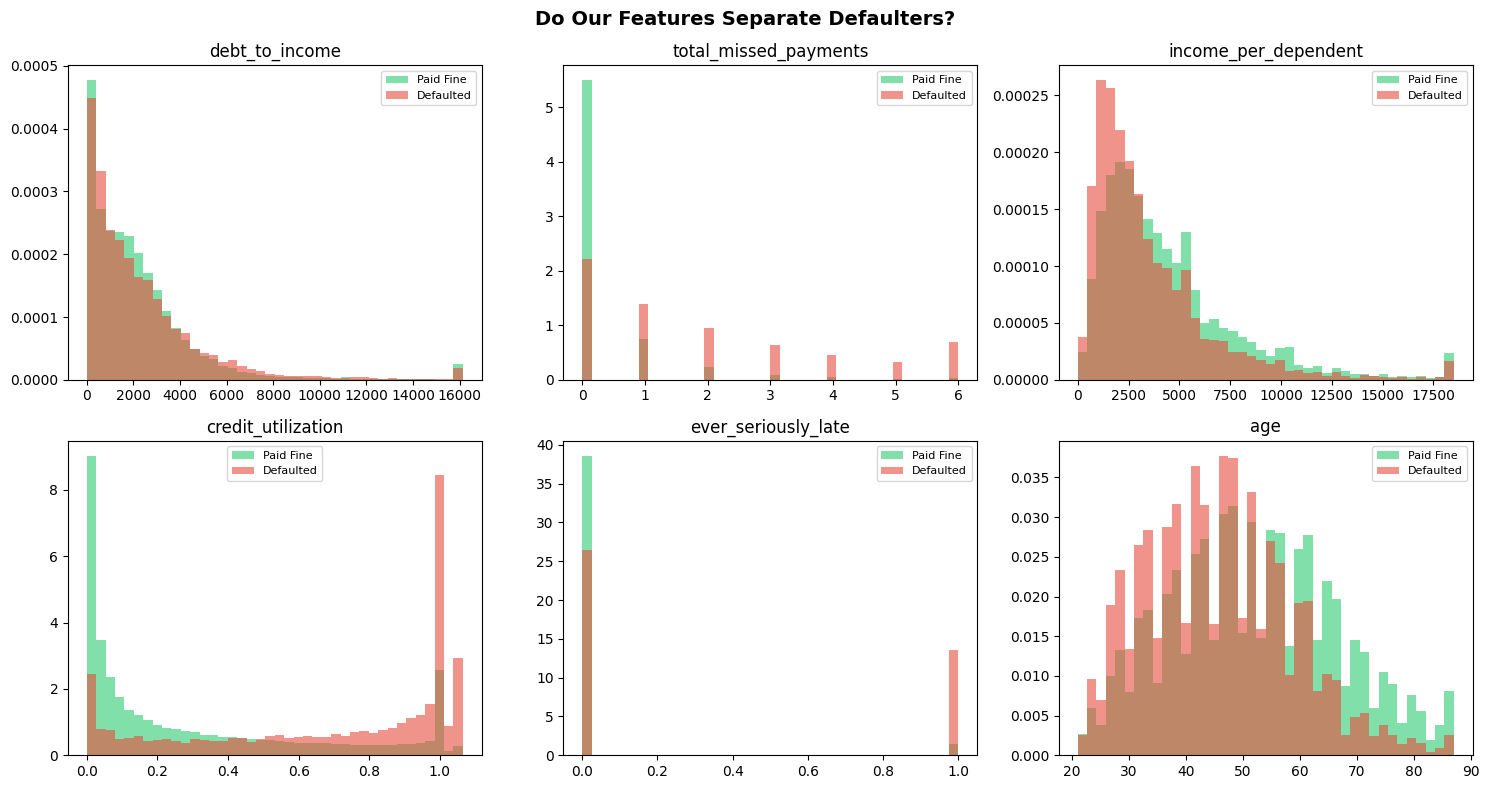

In [6]:
# The whole point of feature engineering is to create signals the model can use
# Let's verify our new features actually differ between defaulters and non-defaulters

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

features_to_check = [
    'debt_to_income',
    'total_missed_payments', 
    'income_per_dependent',
    'credit_utilization',
    'ever_seriously_late',
    'age'
]

for i, feature in enumerate(features_to_check):
    defaulters = df[df['default'] == 1][feature]
    non_defaulters = df[df['default'] == 0][feature]
    
    # Cap at 99th percentile so outliers don't ruin the chart
    cap = df[feature].quantile(0.99)
    
    axes[i].hist(non_defaulters.clip(upper=cap), bins=40, 
                 alpha=0.6, label='Paid Fine', color='#2ecc71', density=True)
    axes[i].hist(defaulters.clip(upper=cap), bins=40, 
                 alpha=0.6, label='Defaulted', color='#e74c3c', density=True)
    axes[i].set_title(feature)
    axes[i].legend(fontsize=8)

plt.suptitle('Do Our Features Separate Defaulters?', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/feature_separation.png', dpi=150)
plt.show()

In [7]:
# ML models only understand numbers — not text like "26-35"
# One-Hot Encoding turns one column with categories into multiple binary columns
# Example: age_group "26-35" becomes:
#   age_group_18-25 = 0
#   age_group_26-35 = 1   ← this one is ON
#   age_group_36-50 = 0
#   etc.

df = pd.get_dummies(df, columns=['age_group'], drop_first=True)

# Separate features (X) from target (y)
# X = everything the model uses as INPUT to make a prediction
# y = what the model is trying to PREDICT (did they default?)
X = df.drop(columns=['default'])
y = df['default']

print(f"Features (X): {X.shape[1]} columns")
print(f"Target (y): {y.value_counts().to_dict()}")
print(f"\nFinal feature list:")
for col in X.columns:
    print(f"  - {col}")

Features (X): 20 columns
Target (y): {0: 112547, 1: 8402}

Final feature list:
  - credit_utilization
  - age
  - missed_30_59
  - debt_ratio
  - monthly_income
  - open_credit_lines
  - missed_90_plus
  - real_estate_loans
  - missed_60_89
  - dependents
  - income_was_missing
  - debt_to_income
  - total_missed_payments
  - income_per_dependent
  - high_credit_utilization
  - ever_seriously_late
  - age_group_26-35
  - age_group_36-50
  - age_group_51-65
  - age_group_65+


In [8]:
# Save our clean, engineered dataset so we don't redo this work in every notebook
df.to_csv('../data/processed_data.csv', index=False)
X.to_csv('../data/X_features.csv', index=False)
y.to_csv('../data/y_target.csv', index=False)

print("✅ Saved:")
print("   data/processed_data.csv  — full cleaned dataset")
print("   data/X_features.csv      — features only")
print("   data/y_target.csv        — target only")
print(f"\n🎯 Ready for modelling!")
print(f"   {X.shape[0]:,} applicants")
print(f"   {X.shape[1]} features")
print(f"   {y.mean()*100:.1f}% default rate")

✅ Saved:
   data/processed_data.csv  — full cleaned dataset
   data/X_features.csv      — features only
   data/y_target.csv        — target only

🎯 Ready for modelling!
   120,949 applicants
   20 features
   6.9% default rate
